In [1]:
import os
import warnings
import requests
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8,5)

In [2]:
API_KEY = "cff749a9ec1044b49953a6f1bbc4cfdf"

SUPPORTED_STOCKS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA"
]

COMPANY_NAMES = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "GOOGL": "Google",
    "AMZN": "Amazon",
    "NVDA": "NVIDIA"
}

In [3]:
def fetch_news(ticker):

    company = COMPANY_NAMES[ticker]

    print("\n" + "="*70)
    print(f"DOWNLOADING NEWS : {company}")
    print("="*70)

    url = (
        "https://newsapi.org/v2/everything?"
        f"q={company}"
        "&language=en"
        "&sortBy=publishedAt"
        "&pageSize=100"
        f"&apiKey={API_KEY}"
    )

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    articles = response.json()["articles"]

    news = pd.DataFrame([

        {
            "Ticker": ticker,
            "Company": company,
            "Date": article["publishedAt"],
            "Title": article["title"],
            "Description": article["description"],
            "Source": article["source"]["name"]
        }

        for article in articles

    ])

    news["Text"] = (
        news["Title"].fillna("") +
        " " +
        news["Description"].fillna("")
    )

    return news

In [4]:
def analyze_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        sentiment = "Positive"

    elif polarity < 0:
        sentiment = "Negative"

    else:
        sentiment = "Neutral"

    return polarity, sentiment

In [5]:
def process_stock_news(ticker):

    news = fetch_news(ticker)

    news[["Polarity", "Sentiment"]] = news["Text"].apply(
        lambda x: pd.Series(analyze_sentiment(x))
    )

    print(news.head())

    return news

In [6]:
def save_news(news, ticker):

    REPORT_DIR = f"../reports/{ticker}"

    os.makedirs(REPORT_DIR, exist_ok=True)

    output_path = os.path.join(
        REPORT_DIR,
        "news_sentiment.csv"
    )

    news.to_csv(
        output_path,
        index=False
    )

    print(f"News dataset saved to: {output_path}")

In [7]:
def sentiment_summary(news):

    print("\nSentiment Summary")
    print("-"*40)

    summary = news["Sentiment"].value_counts()

    print(summary)

    return summary

In [8]:
def plot_sentiment(summary, ticker):

    plt.figure(figsize=(6,5))

    plt.bar(
        summary.index,
        summary.values
    )

    plt.title(f"{ticker} Sentiment Distribution")

    plt.xlabel("Sentiment")

    plt.ylabel("Number of News Articles")

    plt.grid(axis="y")

    plt.show()

In [9]:
def average_sentiment(news):

    avg = news["Polarity"].mean()

    print("\nAverage Polarity :", round(avg,4))

    if avg > 0:
        print("Overall Market Sentiment : Positive")

    elif avg < 0:
        print("Overall Market Sentiment : Negative")

    else:
        print("Overall Market Sentiment : Neutral")

    return avg

In [10]:
def show_top_news(news):

    print("\nTop Positive News")
    print("-"*40)

    positive = news.sort_values(
        "Polarity",
        ascending=False
    ).head(5)

    print(positive[
        ["Title","Polarity"]
    ])

    print("\nTop Negative News")
    print("-"*40)

    negative = news.sort_values(
        "Polarity"
    ).head(5)

    print(negative[
        ["Title","Polarity"]
    ])


DOWNLOADING NEWS : Apple
  Ticker Company                  Date  \
0   AAPL   Apple  2026-07-28T14:55:40Z   
1   AAPL   Apple  2026-07-28T14:55:08Z   
2   AAPL   Apple  2026-07-28T14:53:31Z   
3   AAPL   Apple  2026-07-28T14:53:14Z   
4   AAPL   Apple  2026-07-28T14:52:27Z   

                                               Title  \
0  Apple’s reported ‘HomePad’ may launch as early...   
1  Banks Want Technophobes and Late Adopters to U...   
2  5 Reasons to Buy a MacBook Air Now Instead of ...   
3  S&P 500 futures steady as chip stocks take a t...   
4  Coleen Rooney shows off her gym-honed figure i...   

                                         Description           Source  \
0  For years, we’ve heard rumors of a new home hu...       Biztoc.com   
1  Paze faces an uphill battle to get people to u...       Biztoc.com   
2  Apple's next MacBook Air is several months awa...        MacRumors   
3  The chip sector's downturn could signal broade...  Crypto Briefing   
4          She is k

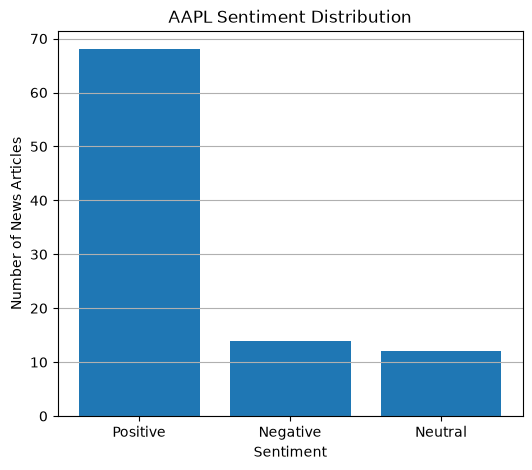

News dataset saved to: ../reports/AAPL\news_sentiment.csv

DOWNLOADING NEWS : Microsoft
  Ticker    Company                  Date  \
0   MSFT  Microsoft  2026-07-28T14:57:31Z   
1   MSFT  Microsoft  2026-07-28T14:56:22Z   
2   MSFT  Microsoft  2026-07-28T14:53:14Z   
3   MSFT  Microsoft  2026-07-28T14:53:00Z   
4   MSFT  Microsoft  2026-07-28T14:52:56Z   

                                               Title  \
0  The OpenAI Hack Is Fueling a New Fight Over Op...   
1  OpenAI CEO Sam Altman says AI has entered the ...   
2  S&P 500 futures steady as chip stocks take a t...   
3  The best AI governance tools and platforms in ...   
4  Virginia Data Centers, Data Center E-Waste, Av...   

                                         Description             Source  \
0  The industry's response to the OpenAI incident...               Time   
1  OpenAI CEO Sam Altman recently declared on the...  Tom's Hardware UK   
2  The chip sector's downturn could signal broade...    Crypto Briefing   
3  A

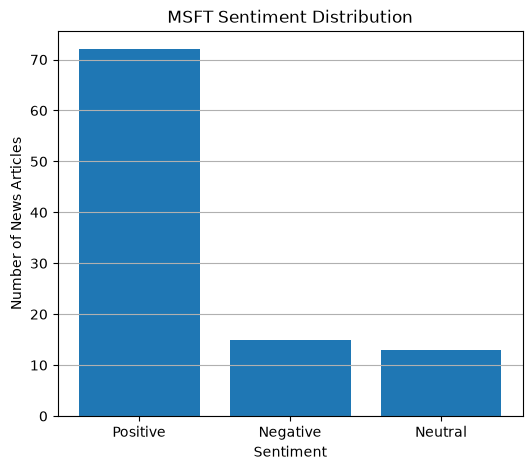

News dataset saved to: ../reports/MSFT\news_sentiment.csv

DOWNLOADING NEWS : Google
  Ticker Company                  Date  \
0  GOOGL  Google  2026-07-28T14:57:31Z   
1  GOOGL  Google  2026-07-28T14:56:22Z   
2  GOOGL  Google  2026-07-28T14:55:41Z   
3  GOOGL  Google  2026-07-28T14:55:40Z   
4  GOOGL  Google  2026-07-28T14:55:19Z   

                                               Title  \
0  The OpenAI Hack Is Fueling a New Fight Over Op...   
1  OpenAI CEO Sam Altman says AI has entered the ...   
2  Cellphone users report outages across major ca...   
3  Apple’s reported ‘HomePad’ may launch as early...   
4  Claude chats showed up in Google Search. Here’...   

                                         Description             Source  \
0  The industry's response to the OpenAI incident...               Time   
1  OpenAI CEO Sam Altman recently declared on the...  Tom's Hardware UK   
2  Customers for several major cell service carri...         Biztoc.com   
3  For years, we’ve heard

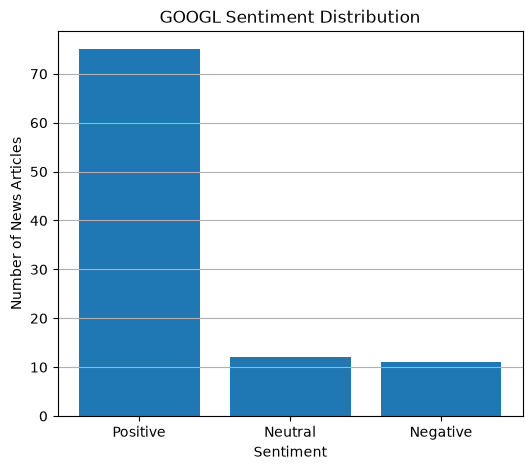

News dataset saved to: ../reports/GOOGL\news_sentiment.csv

DOWNLOADING NEWS : Amazon
  Ticker Company                  Date  \
0   AMZN  Amazon  2026-07-28T14:57:45Z   
1   AMZN  Amazon  2026-07-28T14:57:31Z   
2   AMZN  Amazon  2026-07-28T14:53:31Z   
3   AMZN  Amazon  2026-07-28T14:53:14Z   
4   AMZN  Amazon  2026-07-28T14:52:28Z   

                                               Title  \
0  Add the LEGO Star Wars SMART Play Mos Eisley C...   
1  The OpenAI Hack Is Fueling a New Fight Over Op...   
2  5 Reasons to Buy a MacBook Air Now Instead of ...   
3  S&P 500 futures steady as chip stocks take a t...   
4  Hundreds of Ukrainian Drones Target Moscow in ...   

                                         Description           Source  \
0  We just spotted a deal at Amazon that cuts the...         9to5Toys   
1  The industry's response to the OpenAI incident...             Time   
2  Apple's next MacBook Air is several months awa...        MacRumors   
3  The chip sector's downturn co

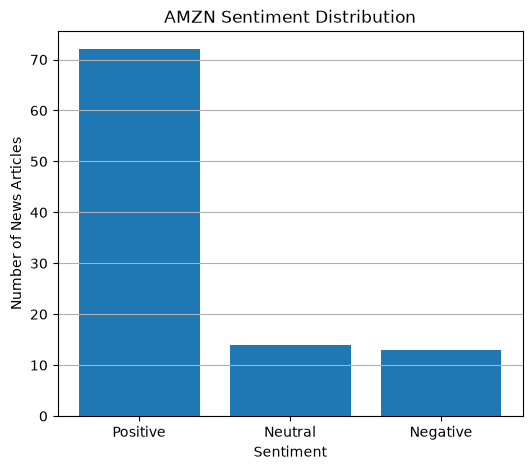

News dataset saved to: ../reports/AMZN\news_sentiment.csv

DOWNLOADING NEWS : NVIDIA
  Ticker Company                  Date  \
0   NVDA  NVIDIA  2026-07-28T14:58:00Z   
1   NVDA  NVIDIA  2026-07-28T14:57:31Z   
2   NVDA  NVIDIA  2026-07-28T14:55:42Z   
3   NVDA  NVIDIA  2026-07-28T14:55:04Z   
4   NVDA  NVIDIA  2026-07-28T14:53:15Z   

                                               Title  \
0  Ace Combat 8 requires ray tracing GPU, 32GB RA...   
1  The OpenAI Hack Is Fueling a New Fight Over Op...   
2  Micron, Nvidia fall after SK Hynix plunges nea...   
3  Nvidia says smuggling is a 'nonstarter' as Tai...   
4  A New AI Shortage Is Coming. One CEO Just Pred...   

                                         Description         Source  \
0  The minimum processor requirement for playing ...       TechSpot   
1  The industry's response to the OpenAI incident...           Time   
2  Semiconductor stocks fell on Tuesday following...     Biztoc.com   
3  A senior sales manager allegedly helpe

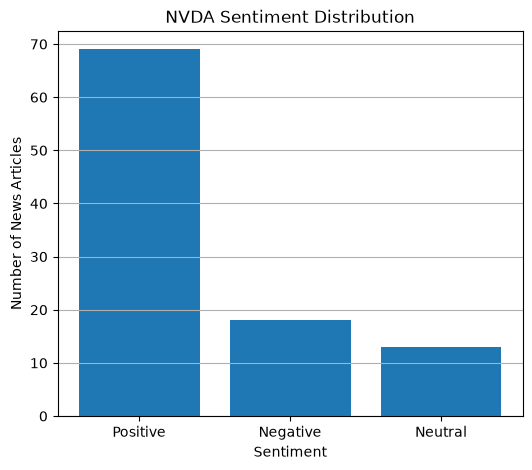

News dataset saved to: ../reports/NVDA\news_sentiment.csv

ALL STOCKS SENTIMENT ANALYSIS COMPLETED


In [11]:
all_news = []

for ticker in SUPPORTED_STOCKS:

    news = process_stock_news(ticker)

    summary = sentiment_summary(news)

    average_sentiment(news)

    show_top_news(news)

    plot_sentiment(
        summary,
        ticker
    )

    save_news(
        news,
        ticker
    )

    all_news.append(news)

combined_news = pd.concat(
    all_news,
    ignore_index=True
)

print("\n" + "="*70)
print("ALL STOCKS SENTIMENT ANALYSIS COMPLETED")
print("="*70)

In [12]:
os.makedirs("../reports", exist_ok=True)

combined_news.to_csv(
    "../reports/all_stocks_sentiment.csv",
    index=False
)

print("Combined report saved successfully.")

Combined report saved successfully.



Average Polarity by Stock
----------------------------------------
Ticker
AAPL     0.131686
AMZN     0.151706
GOOGL    0.143204
MSFT     0.114454
NVDA     0.121511
Name: Polarity, dtype: float64


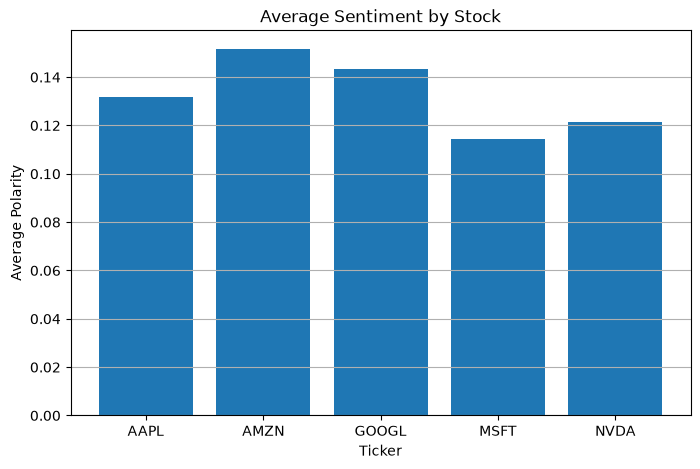

In [13]:
overall = combined_news.groupby(
    "Ticker"
)["Polarity"].mean()

print("\nAverage Polarity by Stock")
print("-"*40)

print(overall)

plt.figure(figsize=(8,5))

plt.bar(
    overall.index,
    overall.values
)

plt.title("Average Sentiment by Stock")

plt.xlabel("Ticker")

plt.ylabel("Average Polarity")

plt.grid(axis="y")

plt.show()